In [1]:
import sys
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Connect to ml directory
ml_root = Path().resolve().parents[0]
sys.path.append(str(ml_root))

# Load the dataset
data_path = ml_root / "data" / "processed" / "train_FD001_features.csv"
train_features = pd.read_csv(data_path)

print("=" * 60)
print(f"Dataset Loaded Successfully: {train_features.shape}")

Dataset Loaded Successfully: (20631, 48)


In [2]:
feature_cols = [c for c in train_features.columns if c not in ["engine_id", "cycle", "RUL"]]

X = train_features[feature_cols]
y = train_features["RUL"]

# Split by Engine ID
engine_ids = train_features["engine_id"].unique()
train_ids, val_ids = train_test_split(engine_ids, test_size=0.20, random_state=42)

train_set = train_features[train_features["engine_id"].isin(train_ids)]
val_set = train_features[train_features["engine_id"].isin(val_ids)]

X_train = train_set[feature_cols]
y_train = train_set["RUL"]

# THE UNTOUCHED VALIDATION SET
X_val = val_set[feature_cols]
y_val = val_set["RUL"]

print("=" * 60)
print("Training Samples   :", X_train.shape)
print("Validation Samples :", X_val.shape)

Training Samples   : (16561, 45)
Validation Samples : (4070, 45)


In [3]:
# 1. Define the Expanded Search Space
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

# 2. Setup Base Model and GroupKFold
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
cv = GroupKFold(n_splits=5)

# 3. Configure Randomized Search
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30, # Increased for better coverage
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# 4. Execute Search (Only on Training Data!)
print("Starting Hyperparameter Tuning...")
search.fit(
    X_train,
    y_train,
    groups=train_set["engine_id"]
)

print("=" * 60)
print("Best Parameters Found:")
print(search.best_params_)

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.8s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=500, subsample=0.7; total time=   5.3s
[CV] END colsample_bytree

In [4]:
artifacts_dir = ml_root / "artifacts"
models_dir = ml_root.parent / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# 1. Save the search object
joblib.dump(search, artifacts_dir / "random_search.pkl")

# 2. Extract and save CV results
cv_results = pd.DataFrame(search.cv_results_)
cv_results = cv_results.sort_values("rank_test_score")
cv_results.to_csv(artifacts_dir / "xgb_search_results.csv", index=False)

# 3. Extract and save the best model
best_xgb = search.best_estimator_
joblib.dump(best_xgb, models_dir / "xgb_rul_model.pkl")

print("=" * 60)
print("Experiment Logs and Best Model Saved Successfully.")
display(cv_results[["rank_test_score", "mean_test_score", "params"]].head(3))

Experiment Logs and Best Model Saved Successfully.


,rank_test_score,mean_test_score,params
17,1,-18.582121,"{'subsample': 0.8, 'n_estimators': 100, 'min_c..."
29,2,-18.634698,"{'subsample': 0.8, 'n_estimators': 300, 'min_c..."
19,3,-18.677188,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."


In [5]:
# Predict on the strictly isolated validation set
tuned_pred = best_xgb.predict(X_val)

tuned_rmse = np.sqrt(mean_squared_error(y_val, tuned_pred))
tuned_mae = mean_absolute_error(y_val, tuned_pred)
tuned_r2 = r2_score(y_val, tuned_pred)

# Hardcoded previous results for comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost Default", "XGBoost Tuned"],
    "RMSE": [20.00, 16.42, 16.41, tuned_rmse],
    "MAE":  [16.12, 11.55, 11.56, tuned_mae],
    "R²":   [0.7702, 0.8451, 0.8452, tuned_r2]
})

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
display(comparison)

FINAL MODEL COMPARISON


,Model,RMSE,MAE,R²
0,Linear Regression,20.000000,16.120000,0.770200
1,Random Forest,16.420000,11.550000,0.845100
2,XGBoost Default,16.410000,11.560000,0.845200
3,XGBoost Tuned,16.428964,12.036583,0.844896


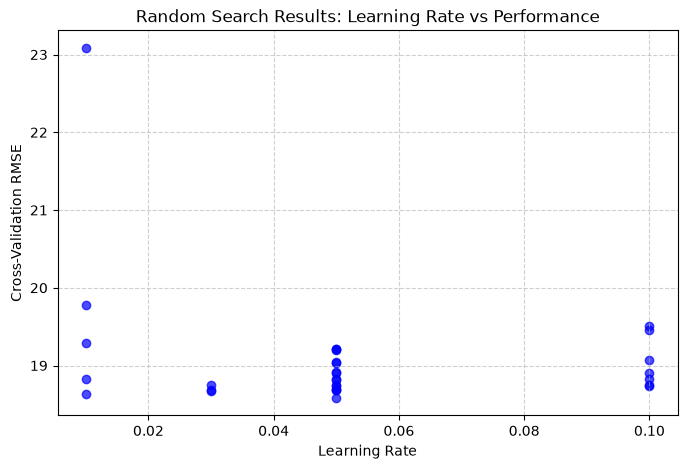

Plot saved to: /Users/princegupta/PredictX-AI/docs/hp_tuning_results.png


In [6]:
plt.figure(figsize=(8,5))
plt.scatter(
    cv_results["param_learning_rate"],
    -cv_results["mean_test_score"],
    alpha=0.7,
    c="blue"
)
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validation RMSE")
plt.title("Random Search Results: Learning Rate vs Performance")
plt.grid(True, linestyle="--", alpha=0.6)

docs_path = ml_root.parent / "docs"
plot_path = docs_path / "hp_tuning_results.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Plot saved to: {plot_path}")